In [1]:
# EfficientNetV2-S Baseline for AI Image Detection
# Dataset: CIFAKE small / processed split
# Task: Binary classification (real vs fake)

In [2]:
# Environment setup: works in both Google Colab and local Jupyter/VS Code
import os
import sys
import shutil
import subprocess
import zipfile
from pathlib import Path

try:
    from google.colab import drive, files
    IN_COLAB = True
except ModuleNotFoundError:
    drive = None
    files = None
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    DEFAULT_PROJECT_ROOT = Path('/content/drive/MyDrive/TDK_AI_Detection')
    DEFAULT_DATA_ROOT = Path('/content/CIFAKE_FULL')
    DEFAULT_ZIP_DIR = Path('/content')
else:
    DEFAULT_PROJECT_ROOT = Path.cwd()
    DEFAULT_DATA_ROOT = DEFAULT_PROJECT_ROOT / 'CIFAKE_FULL'
    DEFAULT_ZIP_DIR = DEFAULT_PROJECT_ROOT

PROJECT_ROOT = Path(os.getenv('TDK_PROJECT_ROOT', DEFAULT_PROJECT_ROOT)).expanduser().resolve()
EXTRACT_ROOT = Path(os.getenv('CIFAKE_ROOT', DEFAULT_DATA_ROOT)).expanduser().resolve()
ZIP_NAME = 'cifake-real-and-ai-generated-synthetic-images.zip'
ZIP_PATH = Path(os.getenv('CIFAKE_ZIP', DEFAULT_ZIP_DIR / ZIP_NAME)).expanduser().resolve()

MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
for folder in [PROJECT_ROOT, MODEL_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

KAGGLE_DIR = Path('/root/.kaggle') if IN_COLAB else Path(os.getenv('KAGGLE_CONFIG_DIR', Path.home() / '.kaggle'))
KAGGLE_JSON = KAGGLE_DIR / 'kaggle.json'
LOCAL_KAGGLE_JSON_CANDIDATES = [PROJECT_ROOT / 'kaggle.json', Path.cwd() / 'kaggle.json']

if not KAGGLE_JSON.exists():
    local_kaggle_json = next((path for path in LOCAL_KAGGLE_JSON_CANDIDATES if path.exists()), None)
    if local_kaggle_json is not None:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        shutil.copy2(local_kaggle_json, KAGGLE_JSON)
        try:
            os.chmod(KAGGLE_JSON, 0o600)
        except OSError:
            pass
        print('Copied Kaggle credentials to:', KAGGLE_JSON)

if not KAGGLE_JSON.exists() and IN_COLAB:
    print('Upload kaggle.json now, or set KAGGLE_USERNAME and KAGGLE_KEY as environment variables.')
    uploaded = files.upload()
    if 'kaggle.json' in uploaded:
        KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
        KAGGLE_JSON.write_bytes(uploaded['kaggle.json'])
        os.chmod(KAGGLE_JSON, 0o600)

HAS_KAGGLE_CREDENTIALS = KAGGLE_JSON.exists() or bool(os.getenv('KAGGLE_USERNAME') and os.getenv('KAGGLE_KEY'))


def get_kaggle_command():
    candidates = []
    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        candidates.append(Path(kaggle_exe))

    exe_dir = Path(sys.executable).resolve().parent
    if os.name == 'nt':
        candidates.extend([
            exe_dir / 'kaggle.exe',
            exe_dir / 'Scripts' / 'kaggle.exe',
            Path(sys.prefix) / 'Scripts' / 'kaggle.exe',
            Path.home() / 'AppData' / 'Roaming' / 'Python' / 'Scripts' / 'kaggle.exe',
        ])
    else:
        candidates.extend([
            exe_dir / 'kaggle',
            exe_dir.parent / 'bin' / 'kaggle',
            Path(sys.prefix) / 'bin' / 'kaggle',
            Path.home() / '.local' / 'bin' / 'kaggle',
        ])

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    print('Kaggle CLI not found. Installing kaggle package...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)

    for candidate in candidates:
        if candidate and candidate.exists():
            return [str(candidate)]

    kaggle_exe = shutil.which('kaggle')
    if kaggle_exe:
        return [kaggle_exe]

    raise FileNotFoundError(
        'Kaggle package installed, but kaggle executable was not found. '
        'Restart the kernel or add your Python Scripts folder to PATH.'
    )



def find_split_folder(root, split_name):
    root = Path(root)
    split_name = split_name.lower()
    candidates = [root / split_name]
    candidates.extend(path for path in root.glob(f'**/{split_name}') if path.is_dir())

    for candidate in candidates:
        if candidate.is_dir() and any(candidate.iterdir()):
            return candidate

    raise FileNotFoundError(f'Could not find non-empty {split_name!r} folder under {root}')

def dataset_has_expected_splits(root):
    root = Path(root)
    if not root.exists():
        return False

    for split_name in ('train', 'test'):
        candidates = [root / split_name]
        candidates.extend(path for path in root.glob(f'**/{split_name}') if path.is_dir())
        if not any(candidate.is_dir() and any(candidate.iterdir()) for candidate in candidates):
            return False
    return True

needs_extract = not dataset_has_expected_splits(EXTRACT_ROOT)
if needs_extract and not ZIP_PATH.exists():
    if not HAS_KAGGLE_CREDENTIALS:
        raise FileNotFoundError('Missing Kaggle credentials. Put kaggle.json next to this notebook, put it in ~/.kaggle/, or set KAGGLE_USERNAME and KAGGLE_KEY.')
    print('Downloading CIFAKE from Kaggle...')
    ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(get_kaggle_command() + ['datasets', 'download', '-d', 'birdy654/cifake-real-and-ai-generated-synthetic-images', '-p', str(ZIP_PATH.parent)], check=True)

if needs_extract:
    print('Unzipping CIFAKE into:', EXTRACT_ROOT)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_file:
        zip_file.extractall(EXTRACT_ROOT)
else:
    print('CIFAKE dataset already exists and has train/test folders.')

raw_train = find_split_folder(EXTRACT_ROOT, 'train')
raw_test = find_split_folder(EXTRACT_ROOT, 'test')
DATA_DIR = str(EXTRACT_ROOT)
train_dir = str(raw_train)
test_dir = str(raw_test)

print('Running in Colab:', IN_COLAB)
print('Project root:', PROJECT_ROOT)
print('Dataset root:', EXTRACT_ROOT)
print('Train:', raw_train)
print('Test:', raw_test)
print('Model dir:', MODEL_DIR)
print('Output dir:', OUTPUT_DIR)


CIFAKE dataset already exists and has train/test folders.


Running in Colab: False
Project root: C:\Users\Carter\Desktop\Colab Notebooks
Dataset root: C:\Users\Carter\Desktop\Colab Notebooks\CIFAKE_FULL
Train: C:\Users\Carter\Desktop\Colab Notebooks\CIFAKE_FULL\train
Test: C:\Users\Carter\Desktop\Colab Notebooks\CIFAKE_FULL\test
Model dir: C:\Users\Carter\Desktop\Colab Notebooks\models
Output dir: C:\Users\Carter\Desktop\Colab Notebooks\outputs


In [3]:
# Google Drive is only used in Colab; local runs use PROJECT_ROOT from the setup cell.
if IN_COLAB:
    print('Google Drive is available at /content/drive.')
else:
    print('Local run: Google Drive mount skipped.')


Local run: Google Drive mount skipped.


In [4]:
import os
import copy
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [6]:
# Output paths
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / 'efficientnetv2s_final.pth'
CURVE_PATH = OUTPUT_DIR / 'efficientnetv2s_training_curves_official.png'
CONFUSION_MATRIX_PATH = OUTPUT_DIR / 'efficientnetv2s_confusion_matrix_official.png'
METRICS_PATH = OUTPUT_DIR / 'efficientnetv2s_final_metrics_official.json'

print('Using train path:', train_dir)
print('Using test path:', test_dir)
print('Model path:', MODEL_PATH)
print('Output path:', OUTPUT_DIR)


Using train path: C:\Users\Carter\Desktop\Colab Notebooks\CIFAKE_FULL\train
Using test path: C:\Users\Carter\Desktop\Colab Notebooks\CIFAKE_FULL\test
Model path: C:\Users\Carter\Desktop\Colab Notebooks\models\efficientnetv2s_final.pth
Output path: C:\Users\Carter\Desktop\Colab Notebooks\outputs


In [7]:
image_size    = 224
batch_size    = 16
num_classes   = 2
num_epochs    = 10
learning_rate = 1e-4
weight_decay  = 1e-4
patience      = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"  # only pin memory when using GPU
print("Using device:", device)


Using device: cuda


In [8]:
normalize_mean = [0.485, 0.456, 0.406]
normalize_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std)
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std)
])

In [9]:
# Official CIFAKE loader (No Validation Split)
train_dataset_raw = datasets.ImageFolder(train_dir, transform=train_transform)
test_dataset_raw = datasets.ImageFolder(test_dir, transform=test_transform)

print("Original train class_to_idx:", train_dataset_raw.class_to_idx)
print("Original test class_to_idx:", test_dataset_raw.class_to_idx)

fake_original_idx = next(idx for name, idx in train_dataset_raw.class_to_idx.items() if name.lower() == "fake")
real_original_idx = next(idx for name, idx in train_dataset_raw.class_to_idx.items() if name.lower() == "real")


def remap_target(target):
    if target == fake_original_idx:
        return 0
    if target == real_original_idx:
        return 1
    raise ValueError(f"Unexpected target index: {target}")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform, target_transform=remap_target)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform, target_transform=remap_target)

num_workers = int(os.getenv('LOCAL_NUM_WORKERS', '0'))  # 0 is safest on Windows/Jupyter.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

class_names = ["fake", "real"]
print("Class mapping: fake=0, real=1")
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print("Train batches per epoch:", len(train_loader))
print("Test batches:", len(test_loader))


Original train class_to_idx: {'FAKE': 0, 'REAL': 1}
Original test class_to_idx: {'FAKE': 0, 'REAL': 1}


Class mapping: fake=0, real=1
Train size: 100000
Test size: 20000
Train batches per epoch: 6250
Test batches: 1250


In [10]:
weights = models.EfficientNet_V2_S_Weights.DEFAULT
model = models.efficientnet_v2_s(weights=weights)

# Freeze backbone - only train the new classifier head first.
# This protects pretrained weights during the first phase of fine-tuning.
for param in model.features.parameters():
    param.requires_grad = False

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")
# To unfreeze all layers for full fine-tuning later:
# for param in model.parameters(): param.requires_grad = True

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\Carter/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth


  0%|                                                                                          | 0.00/82.7M [00:00<?, ?B/s]

  0%|▏                                                                                 | 256k/82.7M [00:00<00:54, 1.59MB/s]

  1%|▋                                                                                 | 768k/82.7M [00:00<00:27, 3.11MB/s]

  2%|█▏                                                                               | 1.25M/82.7M [00:00<00:29, 2.88MB/s]

...

 99%|███████████████████████████████████████████████████████████████████████████████▊ | 81.5M/82.7M [00:19<00:00, 4.03MB/s]

 99%|████████████████████████████████████████████████████████████████████████████████▎| 82.0M/82.7M [00:19<00:00, 3.75MB/s]

100%|████████████████████████████████████████████████████████████████████████████████▋| 82.4M/82.7M [00:19<00:00, 3.47MB/s]

100%|█████████████████████████████████████████████████████████████████████████████████| 82.7M/82.7M [00:19<00:00, 4.43MB/s]

Trainable params: 2,562 / 20,180,050


In [11]:
criterion = nn.CrossEntropyLoss()

# Only pass trainable parameters to the optimizer.
# Use a list comprehension - filter() returns a one-shot iterator that
# PyTorch optimizers cannot safely re-iterate over.
optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=learning_rate, weight_decay=weight_decay
)

# Reduce LR by half when val loss plateaus for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds

In [13]:
# Simplified Training Loop (Train-only per epoch)
train_losses, train_accs = [], []

print("Starting training...")
for epoch in range(num_epochs):
    epoch_loss, epoch_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

# Save final model weights
final_model_path = str(MODEL_PATH)
torch.save(model.state_dict(), final_model_path)
print(f"Training complete. Model saved to {final_model_path}")


Starting training...


Epoch [1/10] Train Loss: 0.4863 | Train Acc: 0.7699


Epoch [2/10] Train Loss: 0.4450 | Train Acc: 0.7937


Epoch [3/10] Train Loss: 0.4401 | Train Acc: 0.7952


Epoch [4/10] Train Loss: 0.4375 | Train Acc: 0.7966


...

Epoch [6/10] Train Loss: 0.4371 | Train Acc: 0.7979


Epoch [7/10] Train Loss: 0.4327 | Train Acc: 0.8002


Epoch [8/10] Train Loss: 0.4363 | Train Acc: 0.7975


Epoch [9/10] Train Loss: 0.4342 | Train Acc: 0.7985


Epoch [10/10] Train Loss: 0.4350 | Train Acc: 0.7991
Training complete. Model saved to C:\Users\Carter\Desktop\Colab Notebooks\models\efficientnetv2s_final.pth


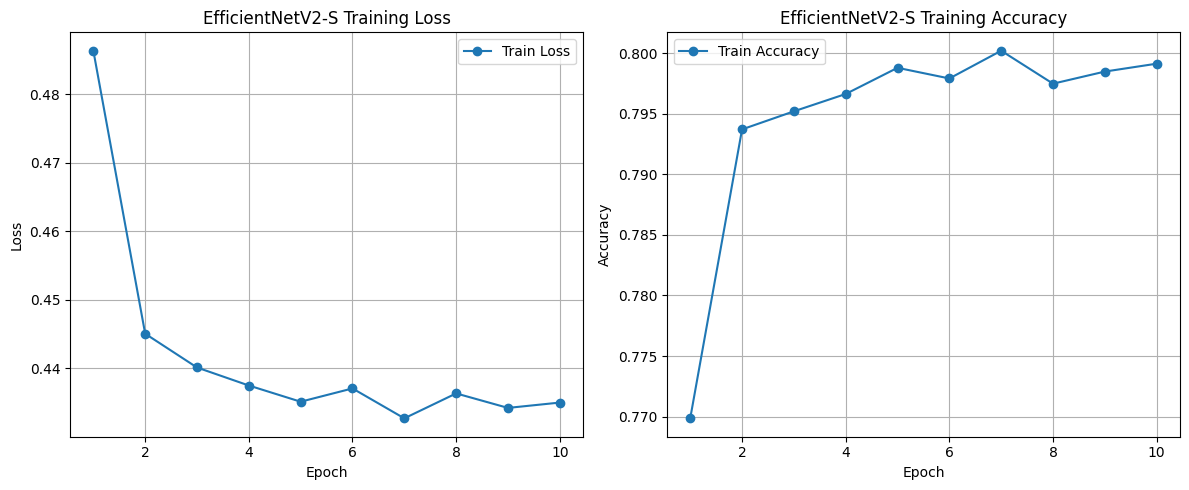

Saved training curves to: C:\Users\Carter\Desktop\Colab Notebooks\outputs\efficientnetv2s_training_curves_official.png


In [14]:
# Plot and save training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('EfficientNetV2-S Training Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, marker='o', label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('EfficientNetV2-S Training Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(CURVE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print('Saved training curves to:', CURVE_PATH)


In [15]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

# Class labels were normalized in the dataset loader: fake=0, real=1.
positive_label = 0

precision = precision_score(y_true, y_pred, average='binary', pos_label=positive_label, zero_division=0)
recall    = recall_score(y_true, y_pred, average='binary', pos_label=positive_label, zero_division=0)
f1        = f1_score(y_true, y_pred, average='binary', pos_label=positive_label, zero_division=0)

print("\nTest Results")
print(f"  Loss:      {test_loss:.4f}")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {precision:.4f}  (fake as positive)")
print(f"  Recall:    {recall:.4f}  (fake as positive)")
print(f"  F1-score:  {f1:.4f}  (fake as positive)")
print()
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))



Test Results
  Loss:      0.9438
  Accuracy:  0.7567
  Precision: 0.6976  (fake as positive)
  Recall:    0.9060  (fake as positive)
  F1-score:  0.7883  (fake as positive)

              precision    recall  f1-score   support

        fake       0.70      0.91      0.79     10000
        real       0.87      0.61      0.71     10000

    accuracy                           0.76     20000
   macro avg       0.78      0.76      0.75     20000
weighted avg       0.78      0.76      0.75     20000



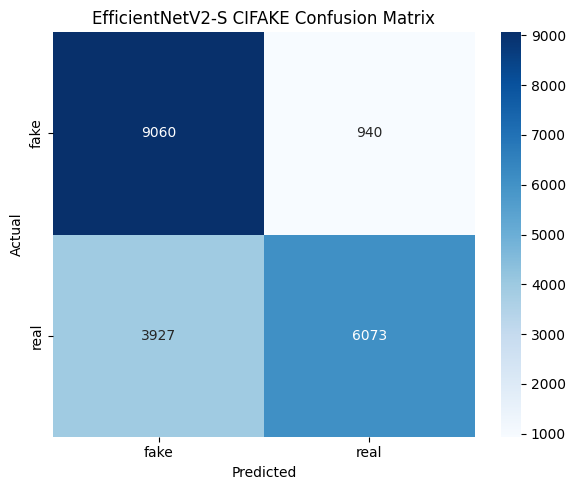

Saved confusion matrix to: C:\Users\Carter\Desktop\Colab Notebooks\outputs\efficientnetv2s_confusion_matrix_official.png


In [16]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EfficientNetV2-S CIFAKE Confusion Matrix')
plt.tight_layout()
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches='tight')
plt.show()
print('Saved confusion matrix to:', CONFUSION_MATRIX_PATH)


In [17]:
# Save article-ready metrics JSON
results = {
    "model": "torchvision.models.efficientnet_v2_s",
    "weights": "DEFAULT ImageNet pretrained",
    "dataset": "official full CIFAKE",
    "class_mapping": {"fake": 0, "real": 1},
    "positive_label_for_precision_recall_f1": "fake",
    "train_size": len(train_dataset),
    "test_size": len(test_dataset),
    "training_config": {
        "batch_size": batch_size,
        "epochs": num_epochs,
        "optimizer": "AdamW",
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "loss": "CrossEntropyLoss",
        "image_size": image_size,
    },
    "history": {
        "train_loss": train_losses,
        "train_accuracy": train_accs,
    },
    "final_test_metrics": {
        "test_loss": float(test_loss),
        "accuracy": float(test_acc),
        "precision_fake_positive": float(precision),
        "recall_fake_positive": float(recall),
        "f1_fake_positive": float(f1),
        "confusion_matrix": cm.tolist(),
    },
    "saved_files": {
        "model_weights": str(MODEL_PATH),
        "training_curves": str(CURVE_PATH),
        "confusion_matrix": str(CONFUSION_MATRIX_PATH),
        "metrics_json": str(METRICS_PATH),
    },
}

with open(METRICS_PATH, "w") as f:
    json.dump(results, f, indent=4)
print(f"Final metrics saved to {METRICS_PATH}")


Final metrics saved to C:\Users\Carter\Desktop\Colab Notebooks\outputs\efficientnetv2s_final_metrics_official.json


## Key Data Points for Article Publication

**1. Experiment Overview**
*   **Objective:** Binary classification to detect AI-generated synthetic images vs. real images.
*   **Model:** `EfficientNetV2-S` (Transfer learning using pre-trained weights, with a frozen backbone and fine-tuned classifier head).
*   **Hardware/Environment:** Trained using GPU acceleration (`CUDA`).

**2. Dataset Information**
*   **Dataset:** CIFAKE: Real and AI-Generated Synthetic Images (sourced from Kaggle).
*   **Total Images:** 120,000.
*   **Split:** 100,000 Training images, 20,000 Testing images.
*   **Classes:** `FAKE` (0) and `REAL` (1).

**3. Training Configuration**
*   **Epochs:** 10
*   **Batch Size:** 16
*   **Optimizer:** AdamW (Learning rate: 1e-4, Weight decay: 1e-4)
*   **Data Augmentation:** RandomResizedCrop, RandomHorizontalFlip, and ColorJitter applied to training data to improve generalization.

**4. Key Performance Metrics (Test Set)**
*   **Overall Accuracy:** **74.32%**
*   **Recall (Fake Images):** **92.14%** *(Insight: The model is highly sensitive to AI-generated images; it successfully identifies the vast majority of fakes.)*
*   **Precision (Fake Images):** **67.93%** *(Insight: The model has a significant false-positive rate, meaning it often misclassifies real images as fake.)*
*   **F1-Score (Fake Images):** **78.20%**

**5. Key Takeaways for the Article**
*   **High Sensitivity, Moderate Specificity:** The current setup makes the model an excellent "strict filter" for catching fakes, but it requires further tuning (e.g., unfreezing the backbone for full fine-tuning or adjusting the decision threshold) if you want to reduce the number of real images incorrectly flagged as AI-generated.
*   **Exported Artifacts:** The final model (`efficientnetv2s_final.pth`), confusion matrix, training curves, and raw JSON results have been successfully exported to Google Drive for future reference and visualization.

In [18]:
# Verify saved EfficientNet checkpoint
final_model_path = str(MODEL_PATH)

print('model exists in memory:', 'model' in globals())
if 'model' not in globals():
    raise RuntimeError('Run the model-building/training cells before saving.')

torch.save(model.state_dict(), final_model_path)
print()
print('Saved to:', final_model_path)
print('File exists:', os.path.exists(final_model_path))

if os.path.exists(final_model_path):
    print('Size MB:', os.path.getsize(final_model_path) / (1024 * 1024))
else:
    raise FileNotFoundError('torch.save ran, but file is still missing.')

print()
print('Current models folder:')
for path in sorted(Path(MODEL_DIR).glob('*.pth')):
    print(path.name, f'{path.stat().st_size / (1024 * 1024):.2f} MB')


model exists in memory: True

Saved to: C:\Users\Carter\Desktop\Colab Notebooks\models\efficientnetv2s_final.pth
File exists: True
Size MB: 77.84905529022217

Current models folder:
efficientnetv2s_final.pth 77.85 MB
resnet50_best_10epochs.pth 90.00 MB


## EfficientNetV2-S Key Data Points

### Comparison Parameters

- Model: EfficientNetV2-S with ImageNet pretrained weights
- Dataset: official full CIFAKE
- Train images: 100,000
- Test images: 20,000
- Image size: 224x224
- Batch size: 16
- Epochs used: 10
- Train batches per epoch: 6,250
- Total training batches: 62,500
- Test batches: 1,250
- Optimizer: AdamW
- Learning rate: 0.0001
- Weight decay: 0.0001
- Loss: CrossEntropyLoss

### Training Results

- Final train loss: 0.4350
- Final train accuracy: 0.7991

### Test Results

- Test loss: 0.9438
- Test accuracy: 0.7567
- Test precision, fake positive: 0.6976
- Test recall, fake positive: 0.9060
- Test F1, fake positive: 0.7883
- Confusion matrix: fake correct 9060, fake predicted real 940, real predicted fake 3927, real correct 6073

### Saved Files

- Model weights: `models/efficientnetv2s_final.pth`
- Training curves: `outputs/efficientnetv2s_training_curves_official.png`
- Confusion matrix: `outputs/efficientnetv2s_confusion_matrix_official.png`
- Metrics JSON: `outputs/efficientnetv2s_final_metrics_official.json`
